# Analyzing Openproblems Results

In [1]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns  # optional, just for color if you like
import matplotlib.pyplot as plt

In [66]:
base_dir = "/Users/seohyon/resources/results"

# will track only these metrics (above BBKNN)
keep_methods = [
    "embed_cell_types_jittered",
    "embed_cell_types",
    "shuffle_integration",
    "scanvi",
    "combat",
    "scvi",
    "harmony",
    "harmonypy",
    "batchelor_fastmnn",
    "liger",
    "pyliger",
    "scalex",
    "uce",
    "no_integration",
    "no_integration_batch",
]

rows = []

# Step 1 — Collect all rows
for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    yaml_path = os.path.join(folder_path, "score_uns.yaml")
    
    if os.path.isdir(folder_path) and os.path.exists(yaml_path):
        with open(yaml_path, "r") as f:
            try:
                data = yaml.safe_load(f)
            except yaml.YAMLError as e:
                print(f"⚠️ Could not read {yaml_path}: {e}")
                continue

        for entry in data:
            method = entry.get("method_id", "").strip().lower()

            # ✅ keep only methods in your whitelist
            if method not in keep_methods:
                continue

            metrics = entry.get("metric_ids", [])
            values = entry.get("metric_values", [])

            for m_id, m_val in zip(metrics, values):
                rows.append({
                    "dataset_id": entry.get("dataset_id"),
                    "file_size": entry.get("file_size"),
                    "method_id": method,
                    "normalization_id": entry.get("normalization_id"),
                    "metric_id": m_id,
                    "metric_value": m_val
                })

# Step 2 — Create one big DataFrame
print("befored dropping NaN:", len(df))
df = pd.DataFrame(rows)
df = df.dropna(subset=["metric_value"]).copy()

print(f"✅ Kept {len(df):,} rows after dropping NaN metric values")


# # Step 3 — Split into separate tables per dataset_id
# datasets = {}
# for dataset_id, sub_df in df.groupby("dataset_id"):
#     datasets[dataset_id] = sub_df.reset_index(drop=True)
#     print(f"\n=== Dataset: {dataset_id} ===")
#     print(sub_df)

#     # Optional: Save each dataset table as its own CSV
#     safe_name = dataset_id.replace("/", "_")  # clean file name
#     output_path = f"/Users/seohyon/resources/{safe_name}_scores.csv"
#     sub_df.to_csv(output_path, index=False)
#     print(f"✅ Saved to {output_path}")



befored dropping NaN: 10221
✅ Kept 12,903 rows after dropping NaN metric values


In [67]:
print(df["dataset_id"].unique())

['openproblems_v1/zebrafish' 'cellxgene_census/dkd'
 'cellxgene_census/tabula_sapiens' 'openproblems_v1/pancreas'
 'cellxgene_census/mouse_pancreas_atlas' 'openproblems_v1/cengen'
 'cellxgene_census/gtex_v9' 'cellxgene_census/hypomap'
 'openproblems_v1/immune_cells' 'cellxgene_census/immune_cell_atlas']


## Per Dataset

In [23]:
dkd_df = pd.read_csv("/Users/seohyon/resources/cellxgene_census_dkd_scores.csv")
gtex_v9_df = pd.read_csv("/Users/seohyon/resources/cellxgene_census_gtex_v9_scores.csv")
hypomap_df = pd.read_csv("/Users/seohyon/resources/cellxgene_census_hypomap_scores.csv")
immune_df = pd.read_csv("/Users/seohyon/resources/cellxgene_census_immune_cell_atlas_scores.csv")
mouse_pan_df = pd.read_csv("/Users/seohyon/resources/cellxgene_census_mouse_pancreas_atlas_scores.csv")
tabula_sapiens_df = pd.read_csv("/Users/seohyon/resources/cellxgene_census_tabula_sapiens_scores.csv")

datasets = {
    "DKD": dkd_df,
    "GTEx v9": gtex_v9_df,
    "HypoMap": hypomap_df,
    "Immune Cell Atlas": immune_df,
    "Mouse Pancreas": mouse_pan_df,
    "Tabula Sapiens": tabula_sapiens_df
}

In [24]:
metrics = sorted(mouse_pan_df["metric_id"].unique().tolist())

print("Unique metrics found:")
for m in metrics:
    print("-", m)

Unique metrics found:
- ari
- ari_batch
- asw_batch
- asw_label
- cell_cycle_conservation
- clisi
- graph_connectivity
- hvg_overlap
- ilisi
- isolated_label_asw
- isolated_label_f1
- kbet
- kbet_pg
- kbet_pg_label
- nmi
- nmi_batch
- pcr


I am assuming that higher score indicates better batch mixing

### Barplot for scores per metric (mouse pancreas)

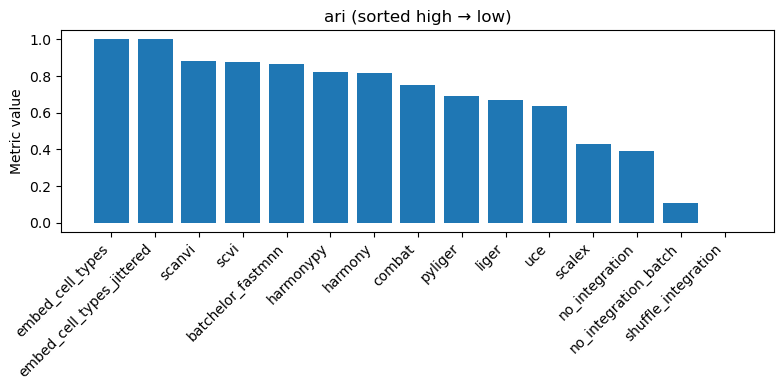

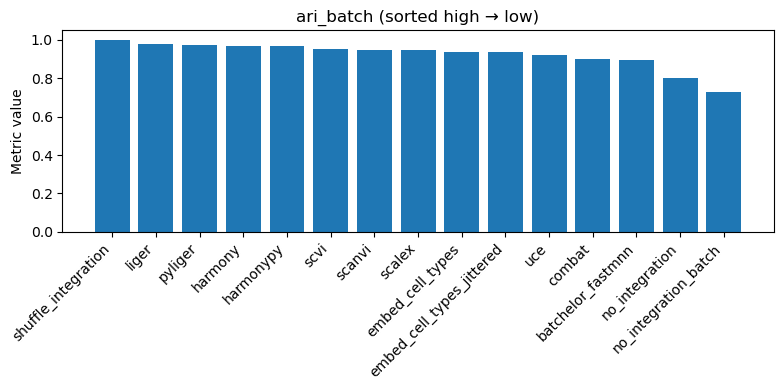

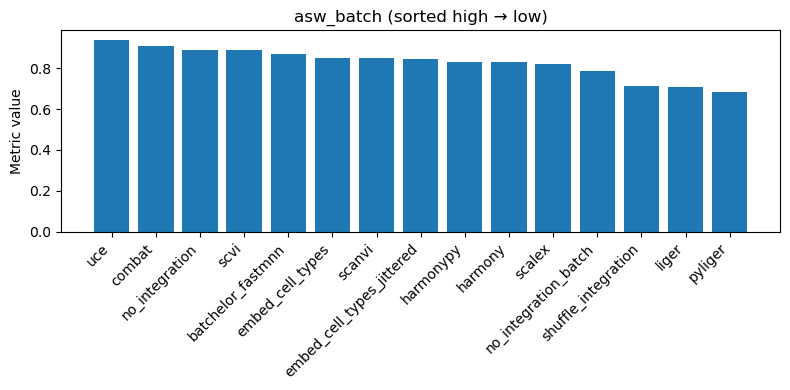

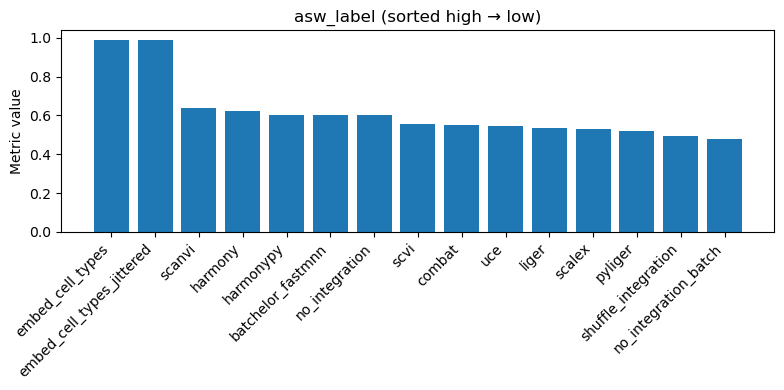

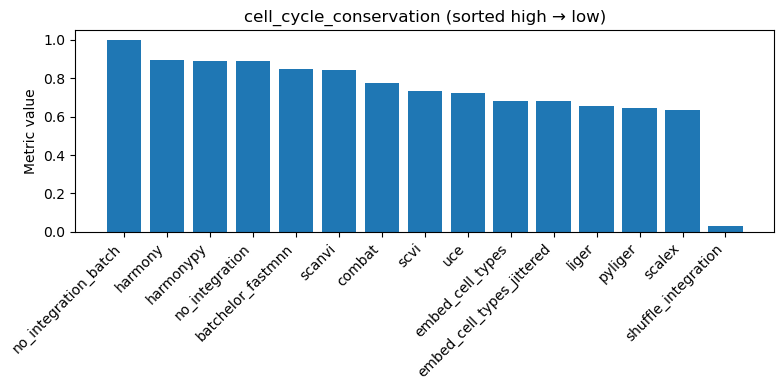

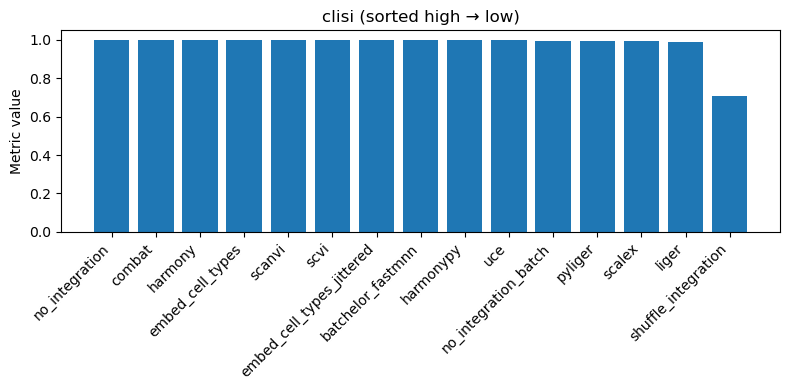

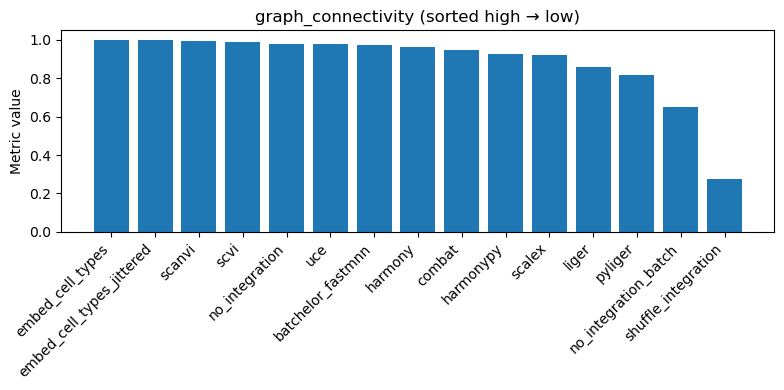

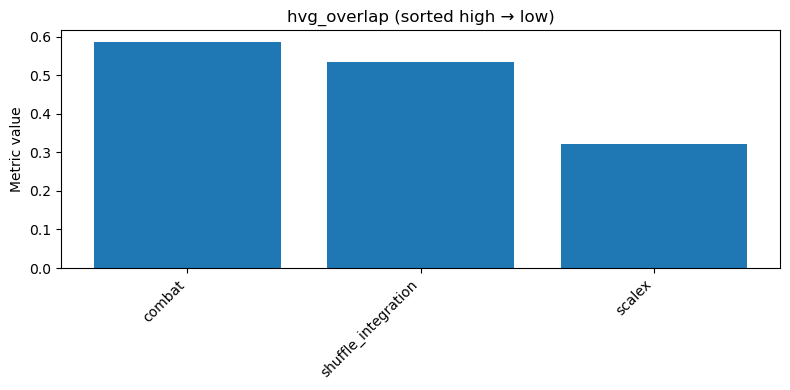

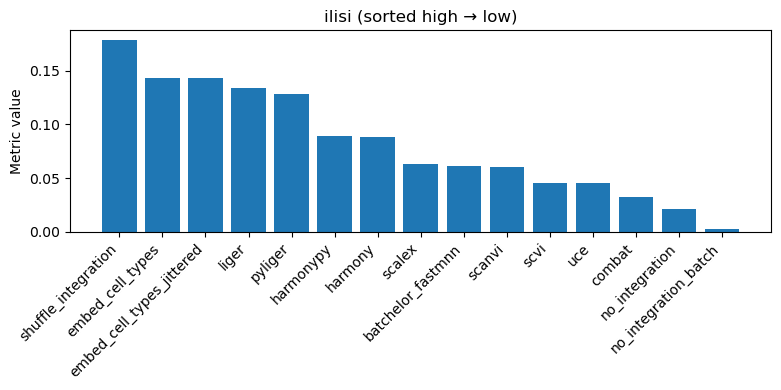

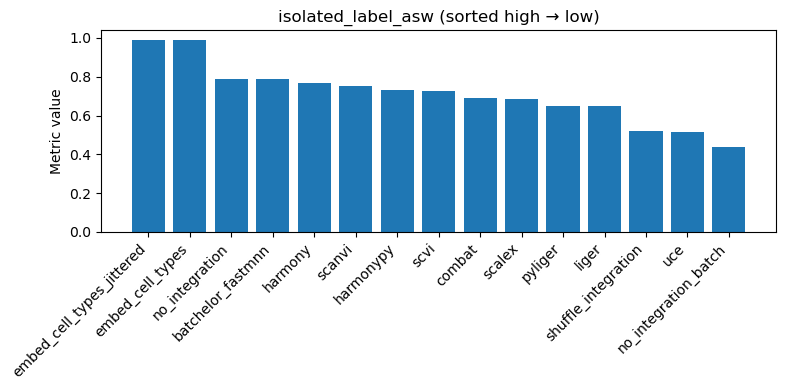

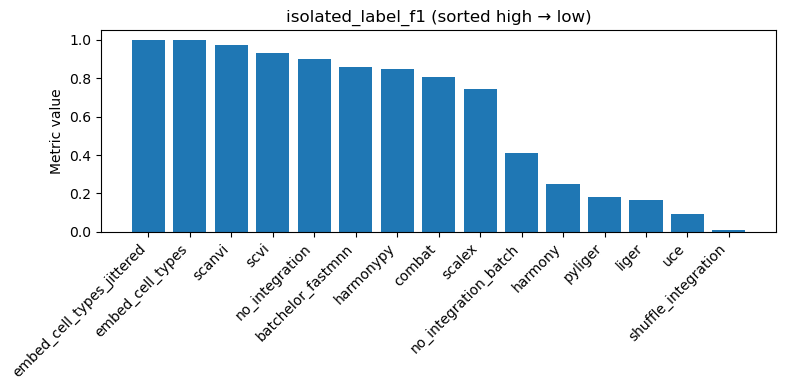

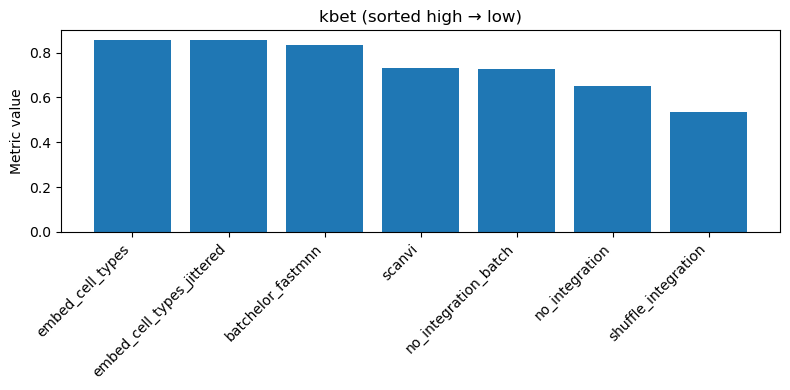

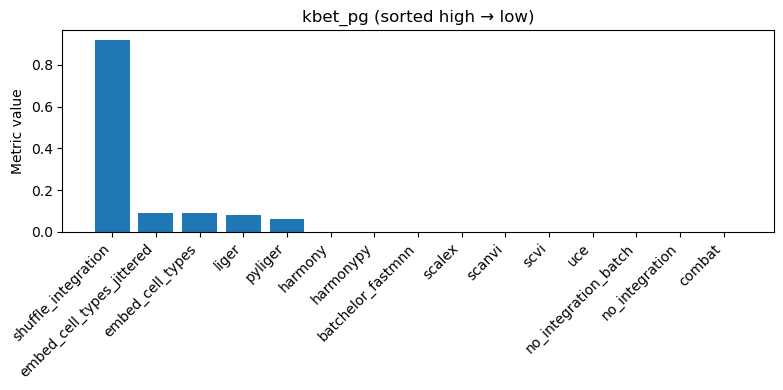

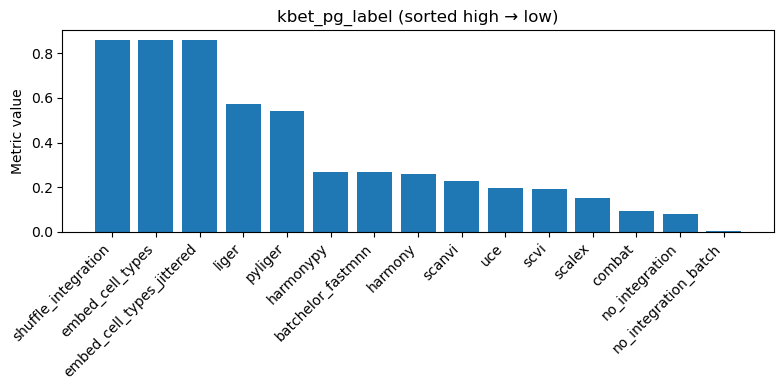

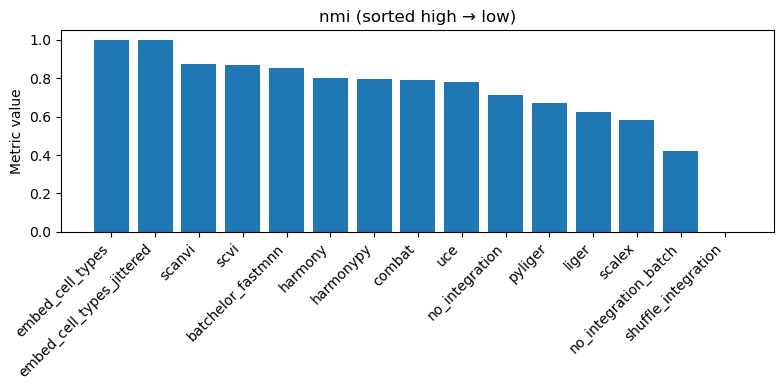

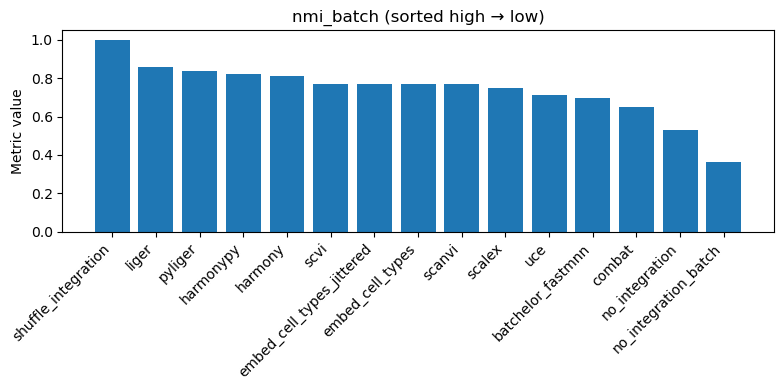

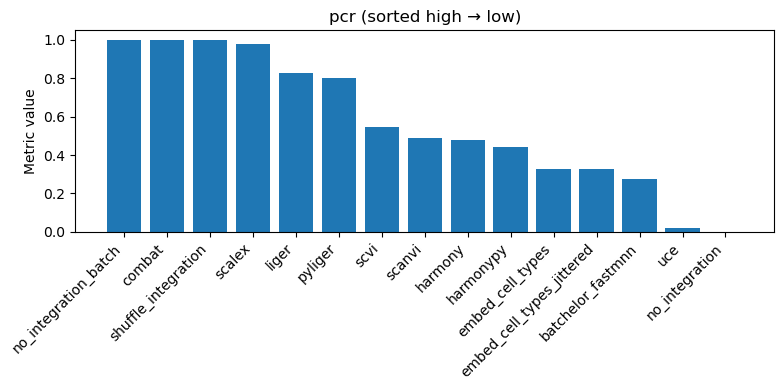

In [25]:
# Loop over each metric
for metric, sub in mouse_pan_df.groupby("metric_id"):
    sub_sorted = sub.sort_values("metric_value", ascending=False)

    plt.figure(figsize=(8, 4))
    plt.bar(sub_sorted["method_id"], sub_sorted["metric_value"])
    plt.title(f"{metric} (sorted high → low)")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Metric value")

    # Save figure per metric
#     safe_metric = metric.replace("/", "_")
#     plt.tight_layout()
#     plt.savefig(f"metric_{safe_metric}.png", dpi=150)
#     plt.close()

    plt.tight_layout()

    plt.show()  # display interactively

# print("✅ All metric bar plots saved as metric_<name>.png")

### Best and Worst Methods

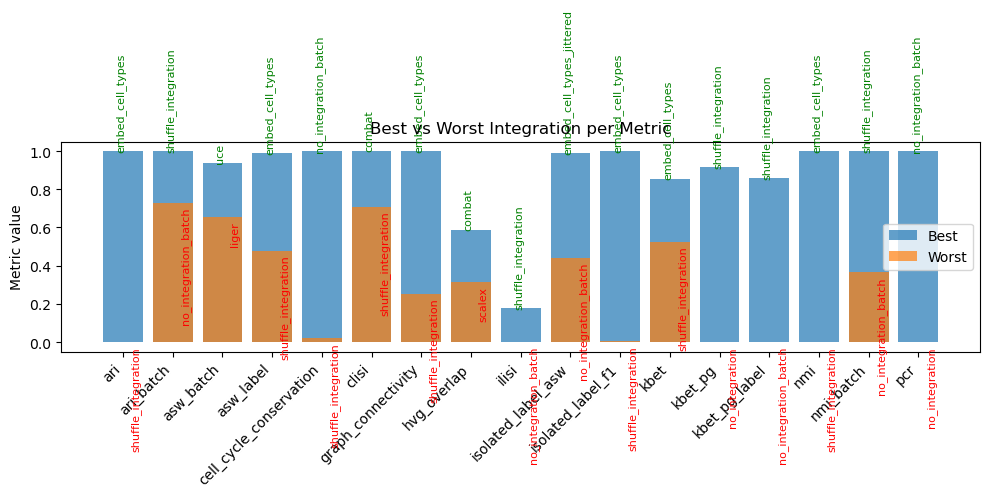

In [28]:
# Find best and worst methods for each metric
best_methods = mouse_pan_df.loc[mouse_pan_df.groupby("metric_id")["metric_value"].idxmax()]
worst_methods = mouse_pan_df.loc[mouse_pan_df.groupby("metric_id")["metric_value"].idxmin()]

plt.figure(figsize=(10, 5))

plt.bar(best_methods["metric_id"], best_methods["metric_value"], label="Best", alpha=0.7)
plt.bar(worst_methods["metric_id"], worst_methods["metric_value"], label="Worst", alpha=0.7)

# Add method names as labels above the bars
for i, (metric, val, method) in enumerate(zip(best_methods["metric_id"], best_methods["metric_value"], best_methods["method_id"])):
    plt.text(i - 0.15, val + 0.01, method, rotation=90, fontsize=8, color="green")

for i, (metric, val, method) in enumerate(zip(worst_methods["metric_id"], worst_methods["metric_value"], worst_methods["method_id"])):
    plt.text(i + 0.15, val - 0.02, method, rotation=90, fontsize=8, color="red", va="top")

# Cosmetics
plt.title("Best vs Worst Integration per Metric")
plt.ylabel("Metric value")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Thoughts: ASW_batch has high metric scores for all of the methods. Let's look into no_integration_batch - this one is not integrated by batch but still got almost 0.8 with ASW_batch. Is ASW_batch reliable?

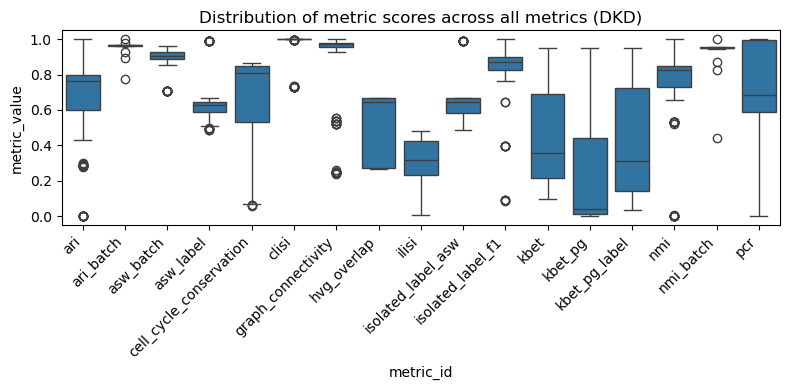

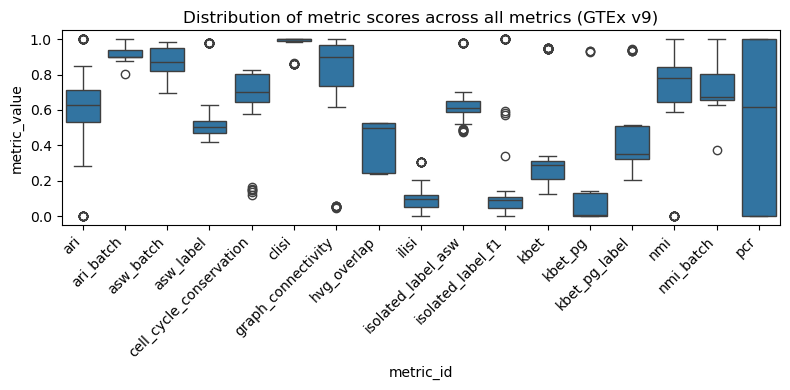

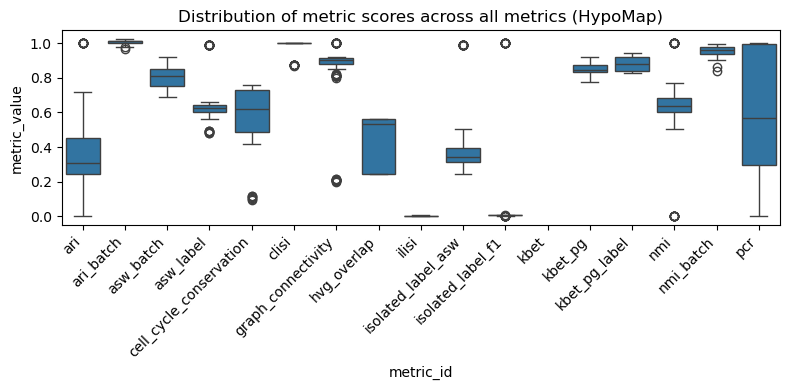

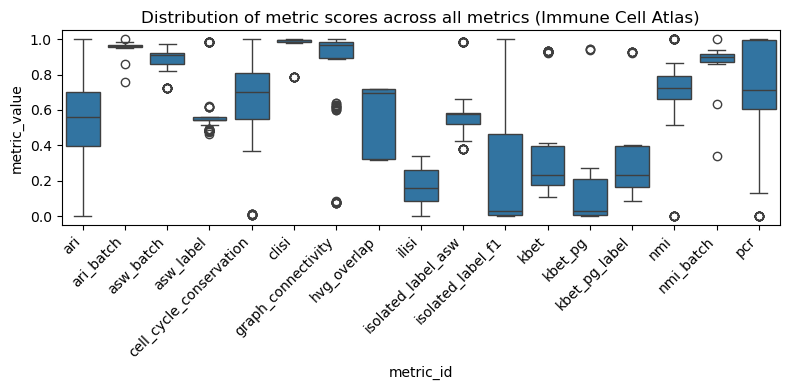

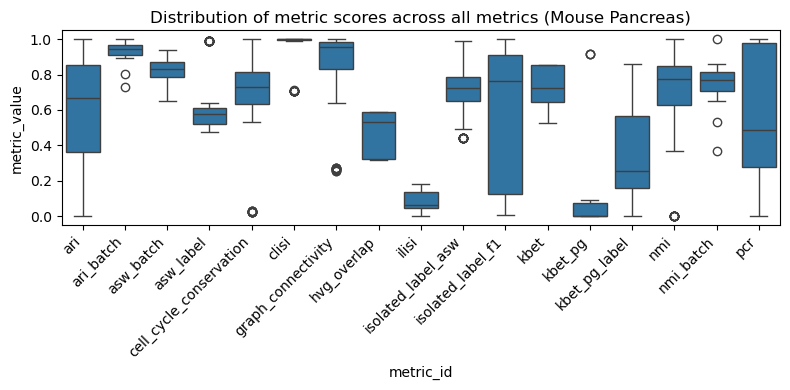

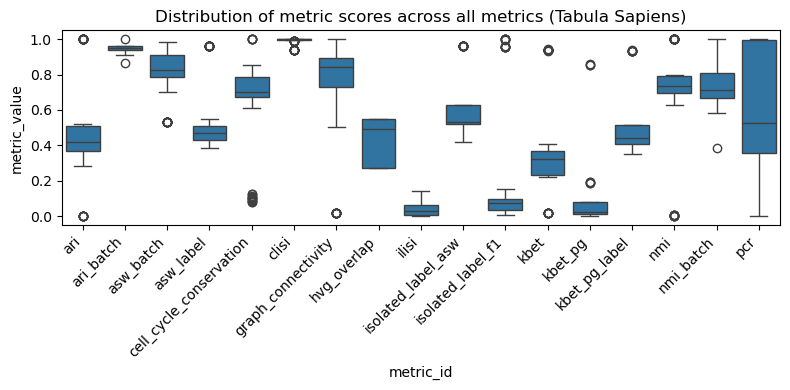

In [33]:
metric_order = sorted(
    set().union(*[df["metric_id"].unique() for df in datasets.values()])
)

for name, df in datasets.items():
    plt.figure(figsize=(8,4))
    sns.boxplot(x="metric_id", y="metric_value", data=df, order=metric_order)
    plt.title(f"Distribution of metric scores across all metrics ({name})")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

e.g. ari_batch performed very well in every datasets

### Adding dataset characteristics to the big df

In [69]:
meta = pd.read_csv("/Users/seohyon/resources/Batch_Integration_Dataset - Tabellenblatt2.csv")
df["dataset_id"] = df["dataset_id"].str.split("/").str[-1] # make them the same name to merge

print(meta["dataset"].unique())
print(df["dataset_id"].unique())

df = pd.merge(df, meta, left_on="dataset_id", right_on="dataset", how="inner").drop(columns=["dataset"])

['mouse_pancreas_atlas' 'dkd' 'immune_cell_atlas' 'gtex_v9' 'hypomap'
 'tabula_sapiens']
['zebrafish' 'dkd' 'tabula_sapiens' 'pancreas' 'mouse_pancreas_atlas'
 'cengen' 'gtex_v9' 'hypomap' 'immune_cells' 'immune_cell_atlas']


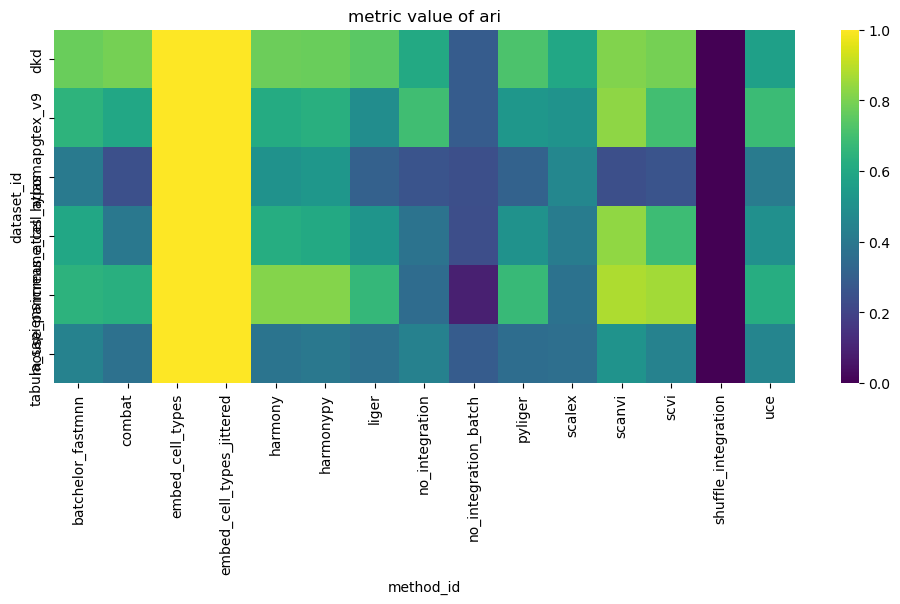

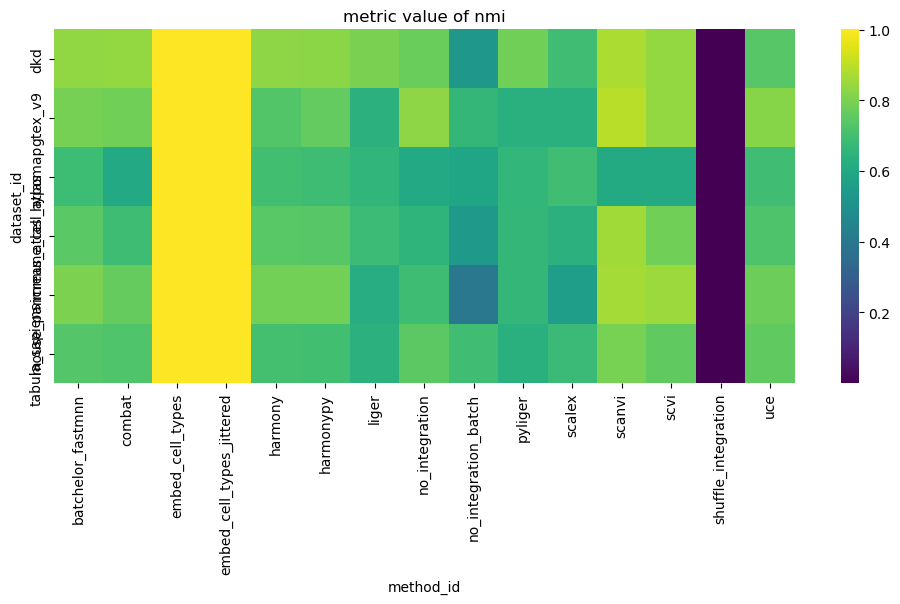

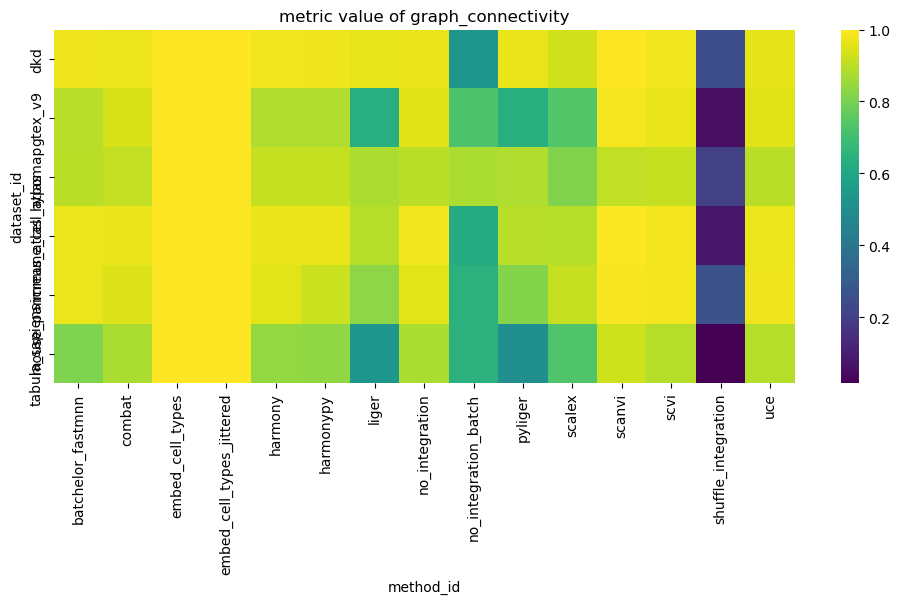

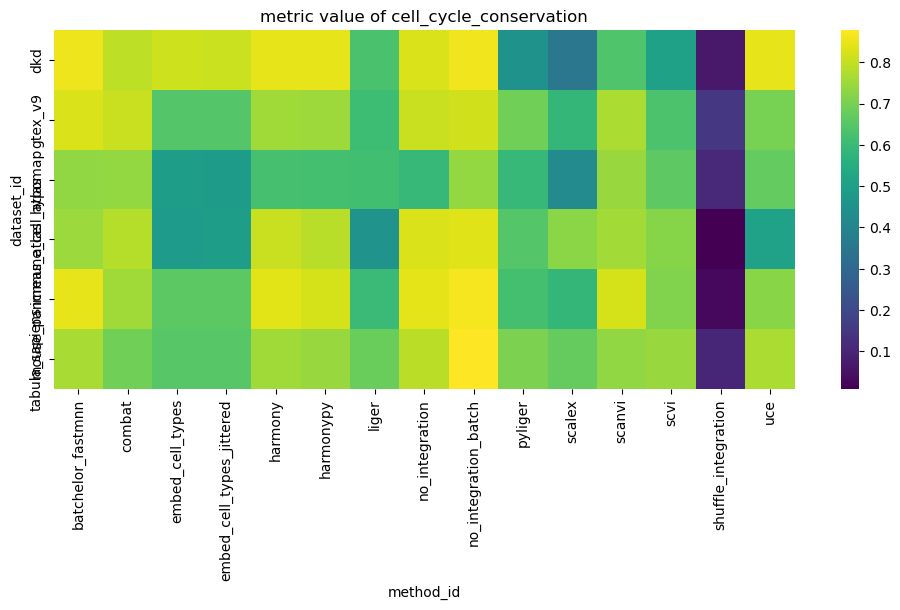

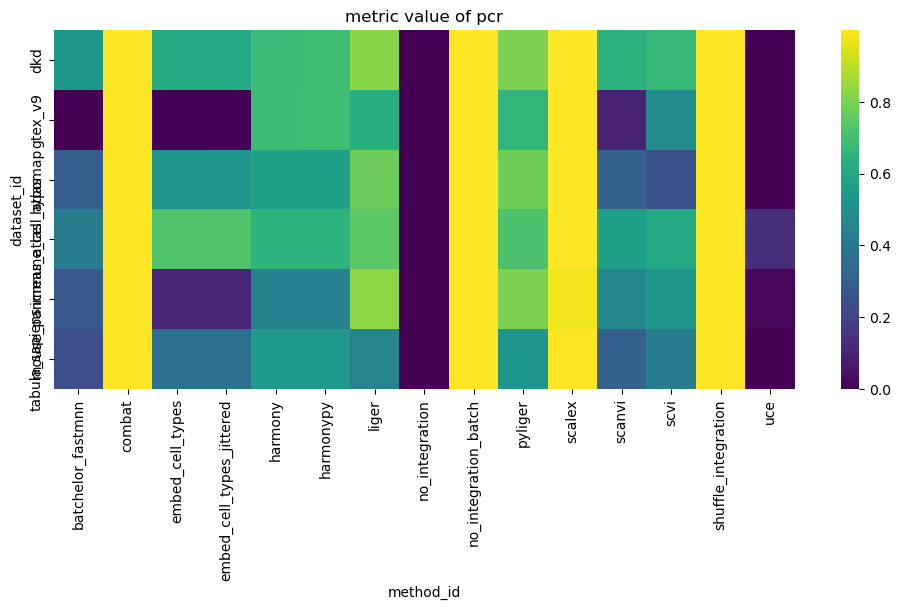

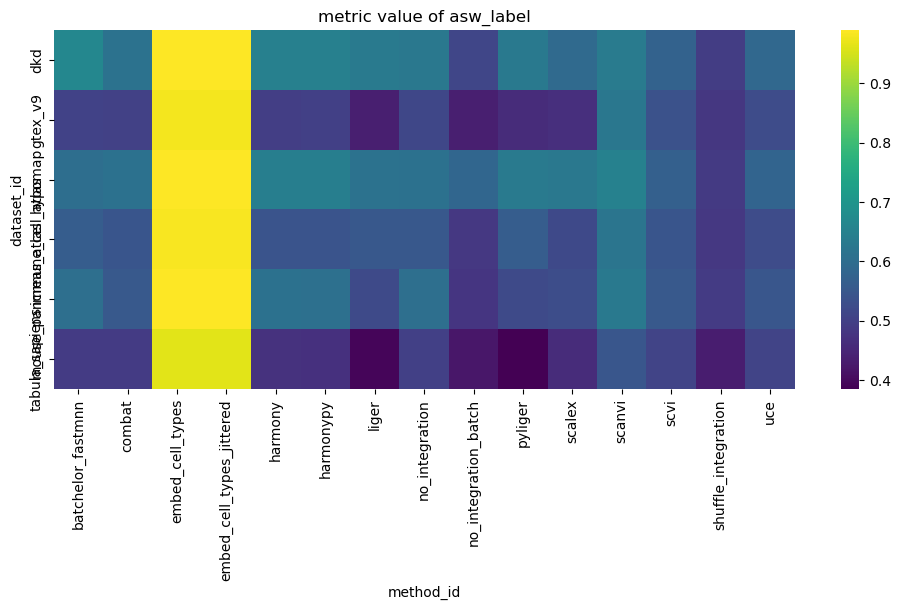

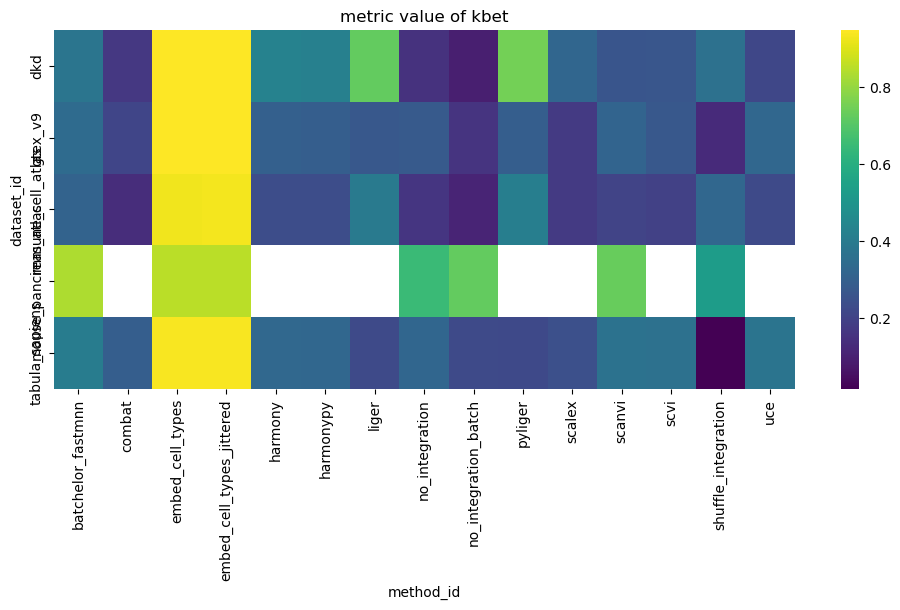

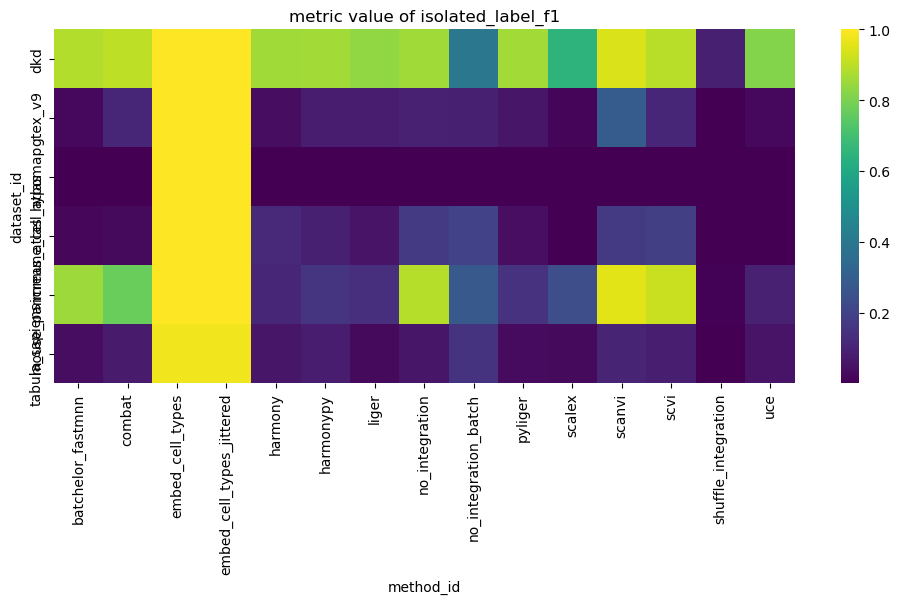

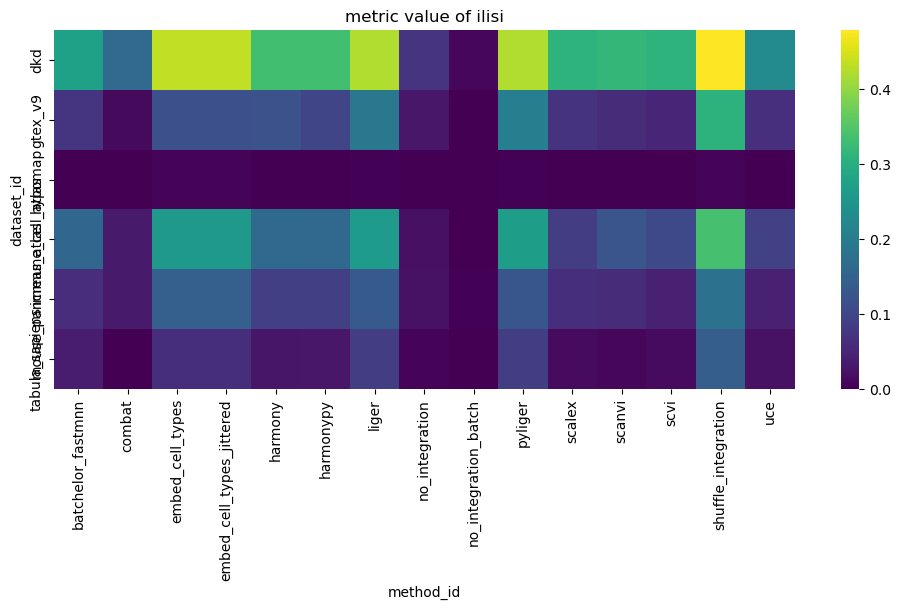

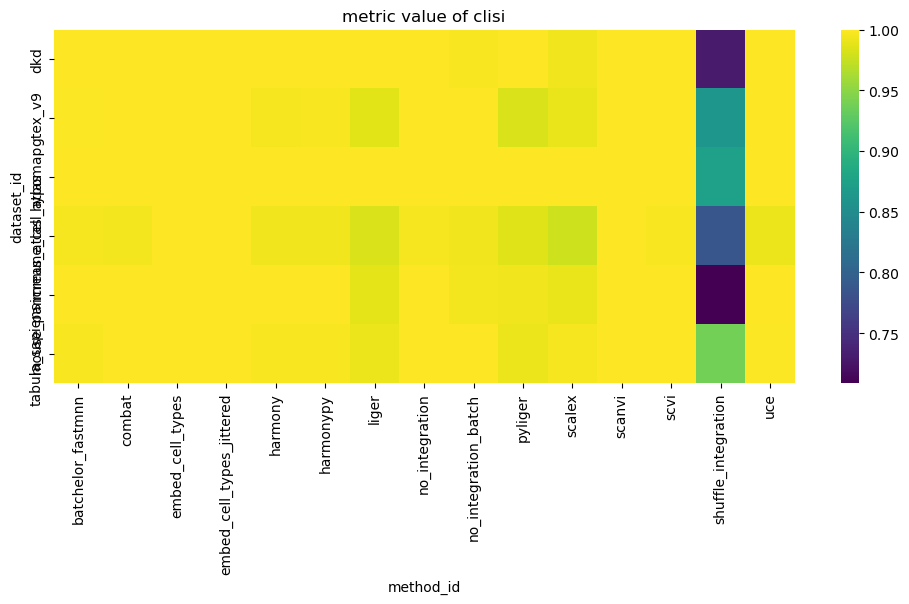

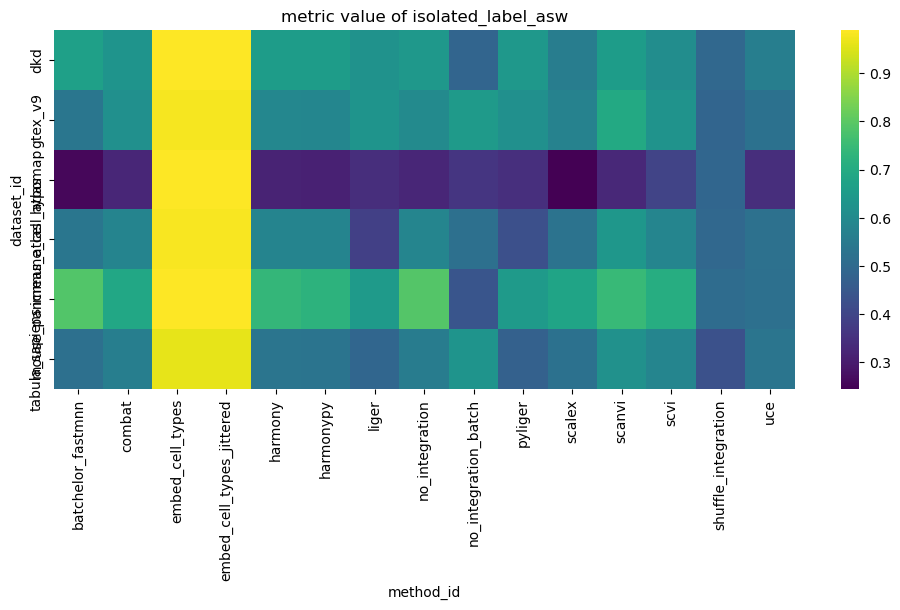

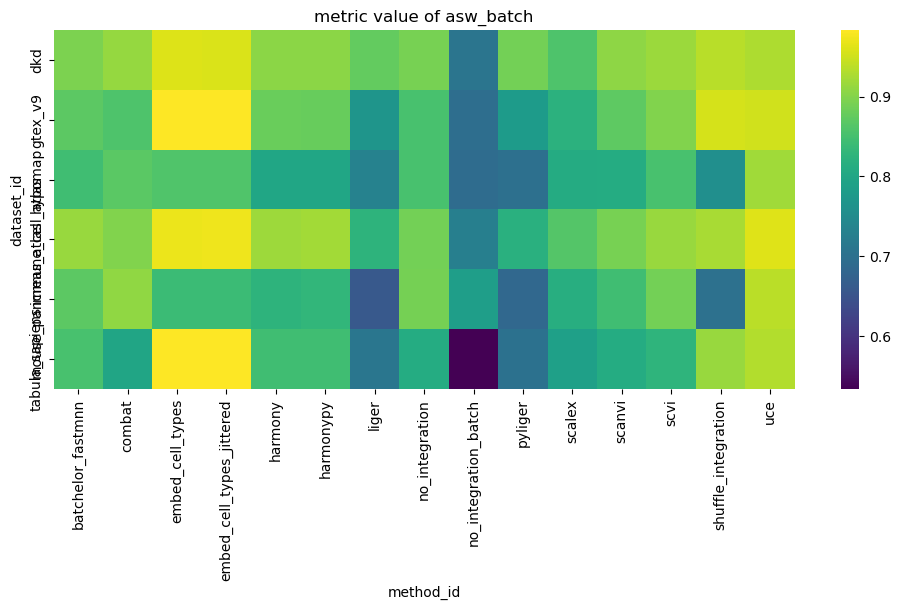

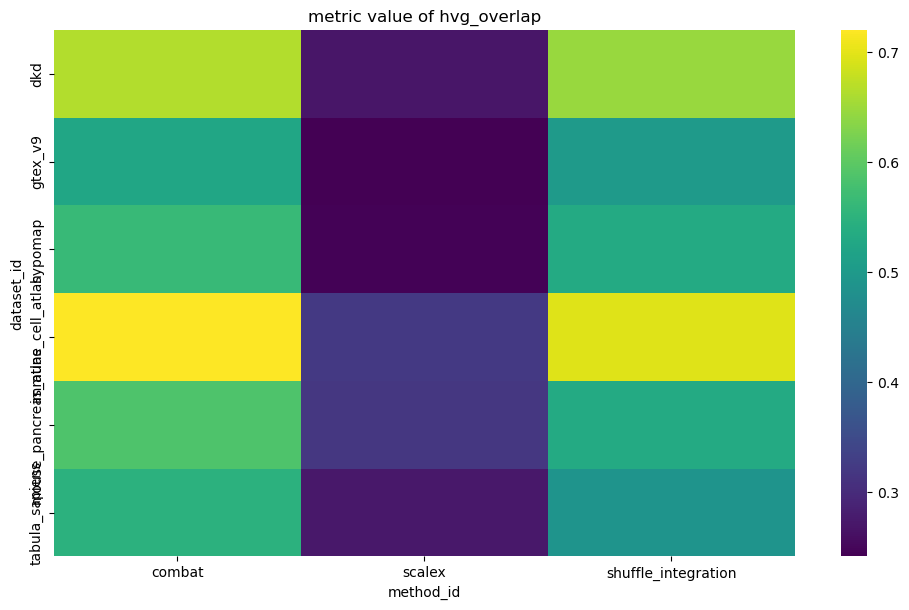

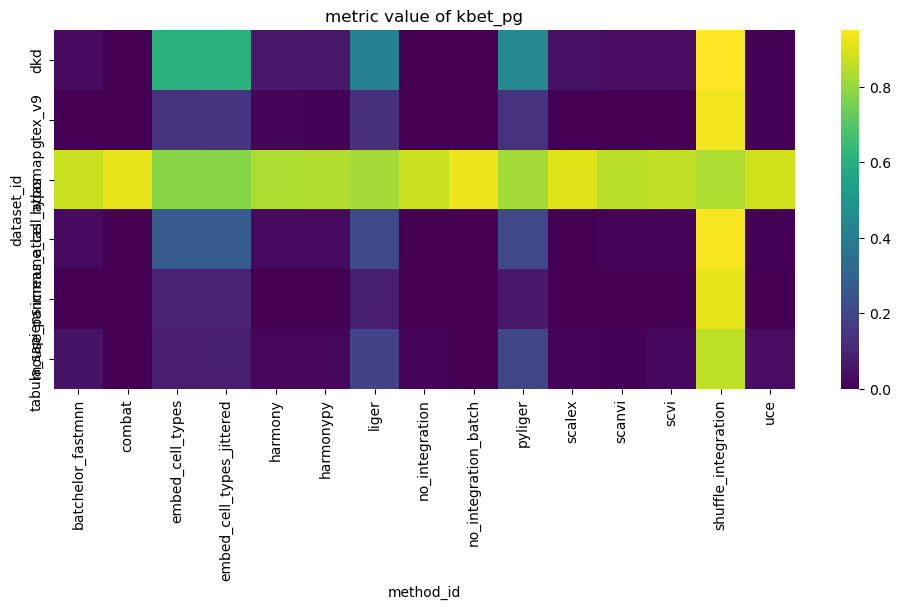

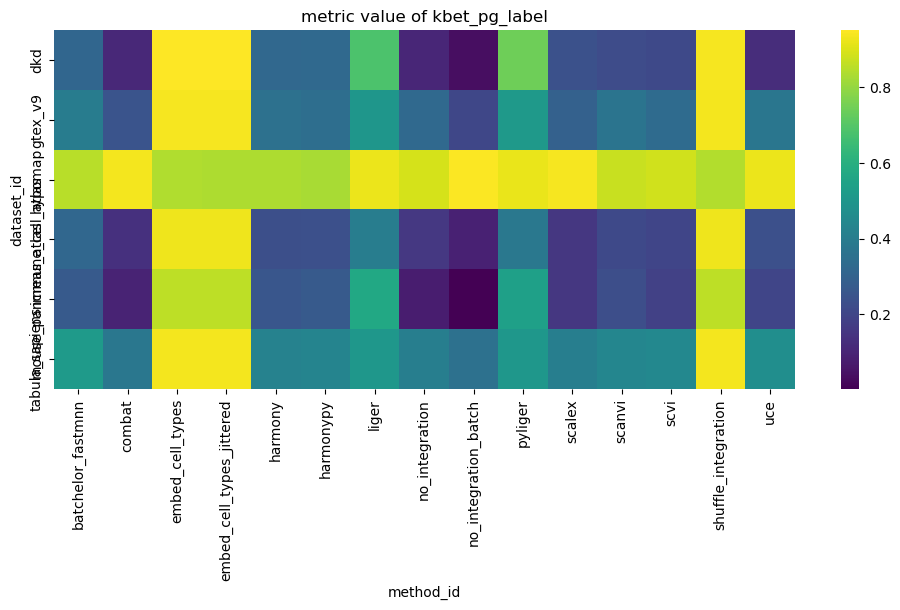

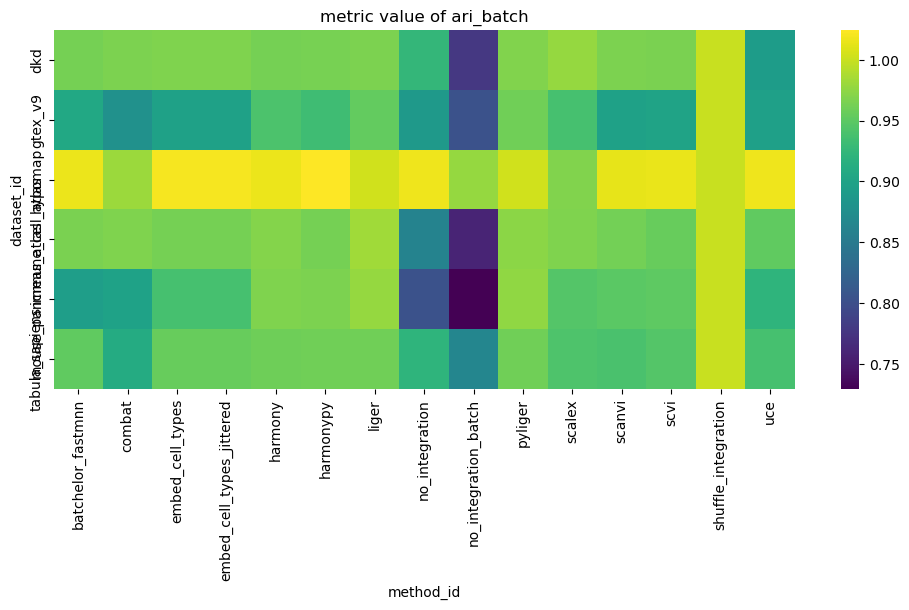

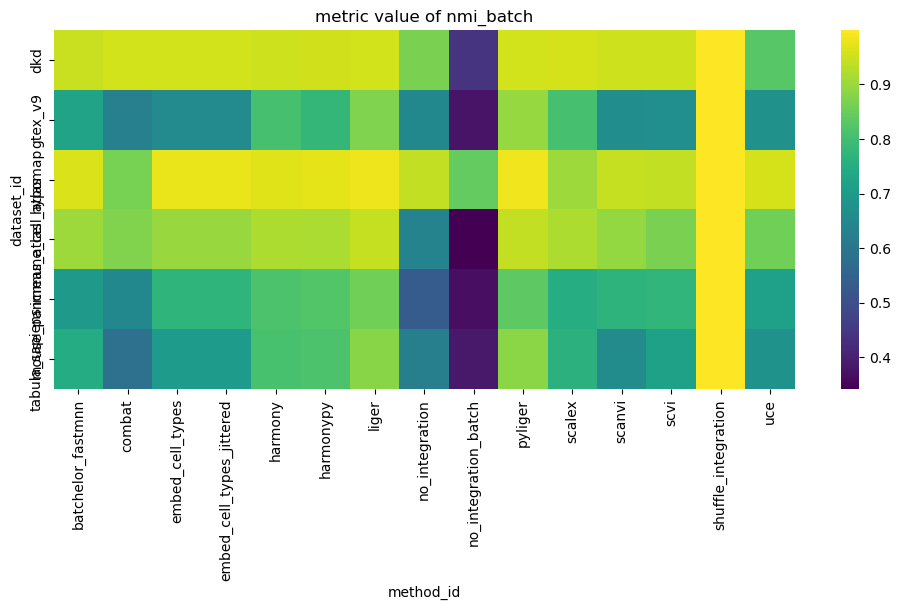

In [100]:
for metric in df["metric_id"].unique():
    sub = df[df["metric_id"] == metric]

    pv = sub.pivot_table(
        index="dataset_id",
        columns="method_id",
        values="metric_value",
        # aggfunc="first"   # use raw values (no averaging)
    )
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pv, cmap="viridis", ax=ax)
    
    ax.tick_params(axis="y", labelrotation=90) # doesn't work I give up
    
    plt.tight_layout()
    plt.title(f"metric value of {metric}")
    plt.show()

Consider kicking out that one dataset that failed for kBET

### Metric dependence on dataset characteristics

In [107]:
df["metric_id"].unique()

array(['ari', 'nmi', 'graph_connectivity', 'cell_cycle_conservation',
       'pcr', 'asw_label', 'kbet', 'isolated_label_f1', 'ilisi', 'clisi',
       'isolated_label_asw', 'asw_batch', 'hvg_overlap', 'kbet_pg',
       'kbet_pg_label', 'ari_batch', 'nmi_batch'], dtype=object)

<Axes: >

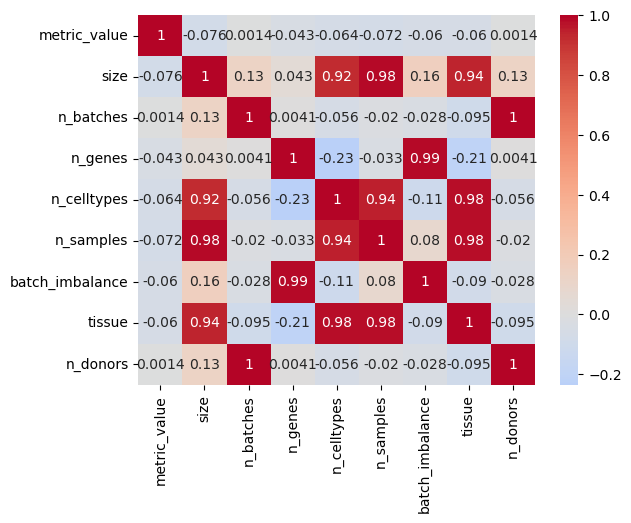

In [74]:
num_cols = ["metric_value","size","n_batches","n_genes","n_celltypes","n_samples","batch_imbalance","tissue","n_donors"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

One correlation thingy for dataset features - are the features correlated to eachother

metric vs dataset feature 

### metric value vs number of cells

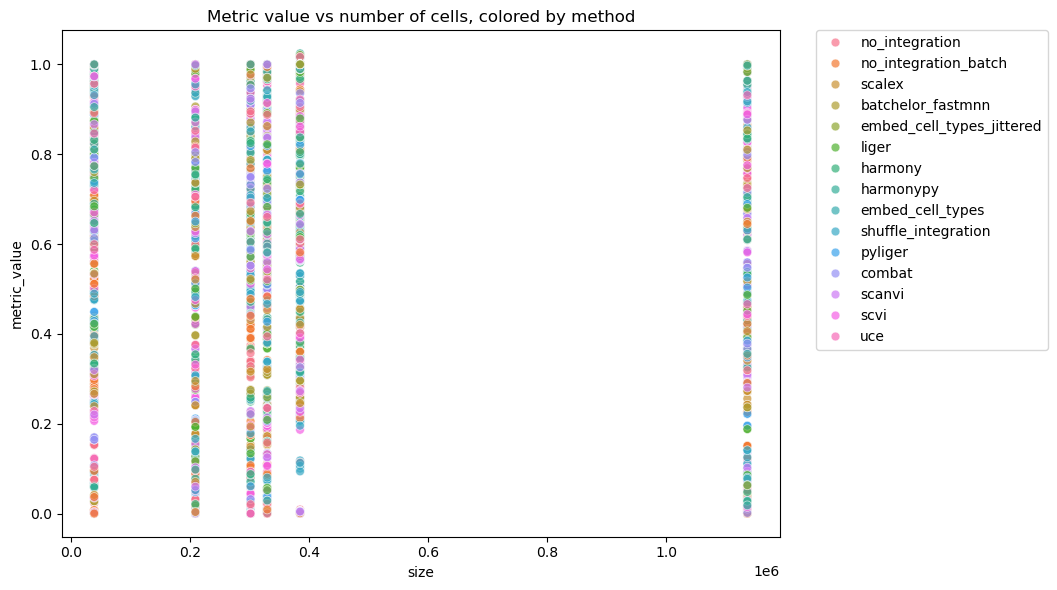

In [80]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="size",
    y="metric_value",
    hue="method_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs number of cells, colored by method")
plt.tight_layout()

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.show()

DO PER METRIC

color them by control vs non-control or leave control out

seaborn catplot strip plot(?)

put jitter

### metric value - n_genes

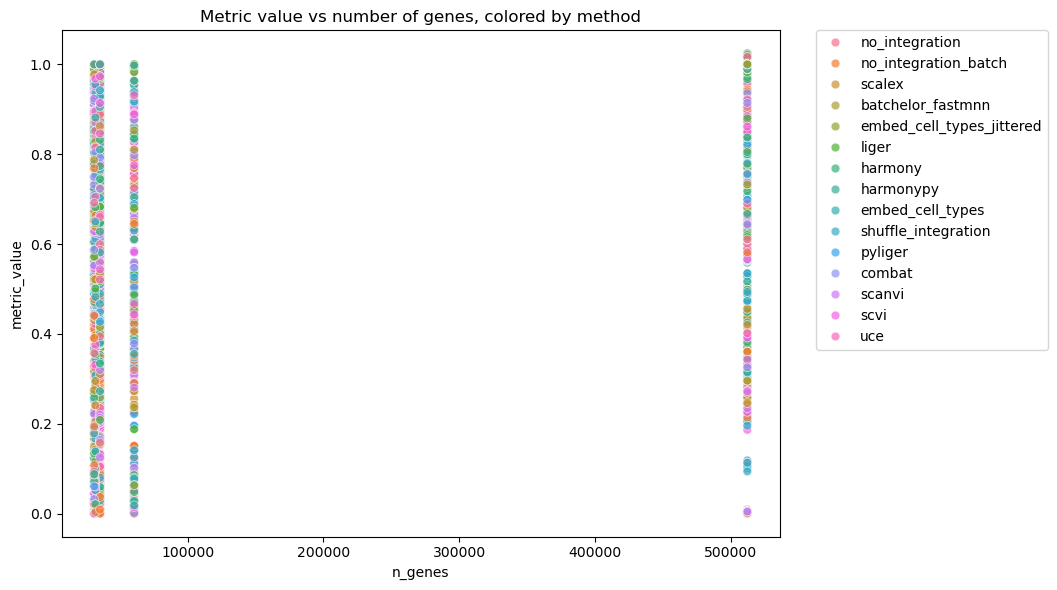

In [86]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="n_genes",
    y="metric_value",
    hue="method_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs number of genes, colored by method")
plt.tight_layout()

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.show()

### metric value - tissue

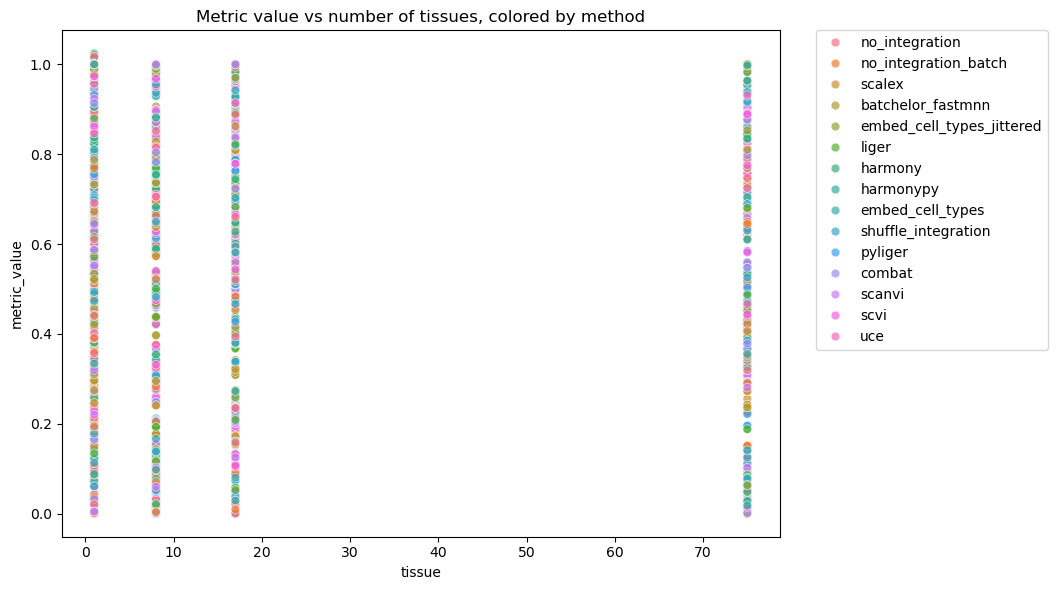

In [87]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="tissue",
    y="metric_value",
    hue="method_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs number of tissues, colored by method")
plt.tight_layout()

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.show()

### Metric value - number of Batches

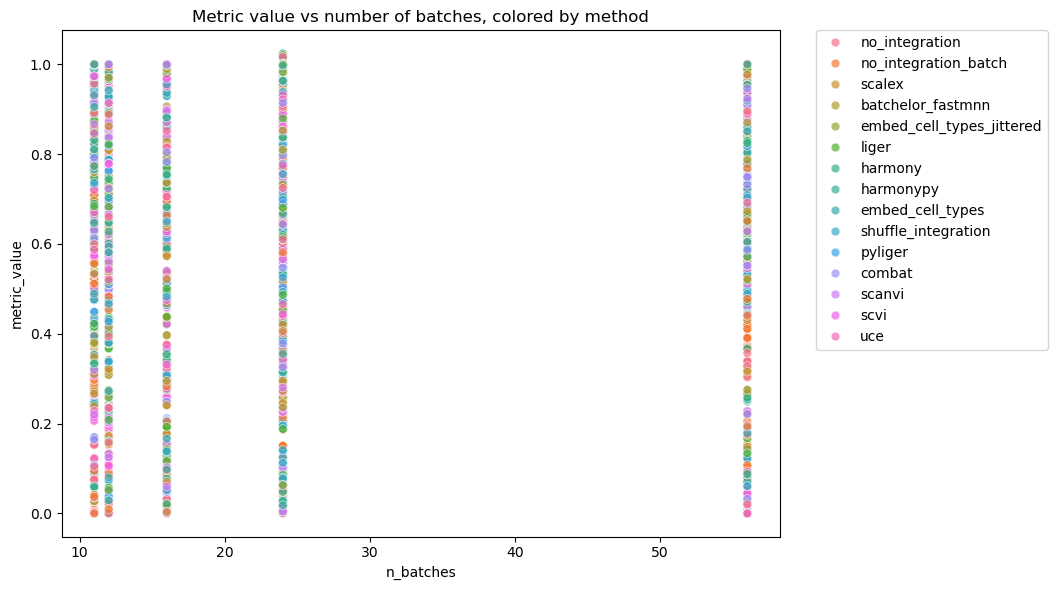

In [88]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="n_batches",
    y="metric_value",
    hue="method_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs number of batches, colored by method")
plt.tight_layout()

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.show()

=> separate plot per metric or color by metric instead of method

### Colored by metric: metric value - number of cells

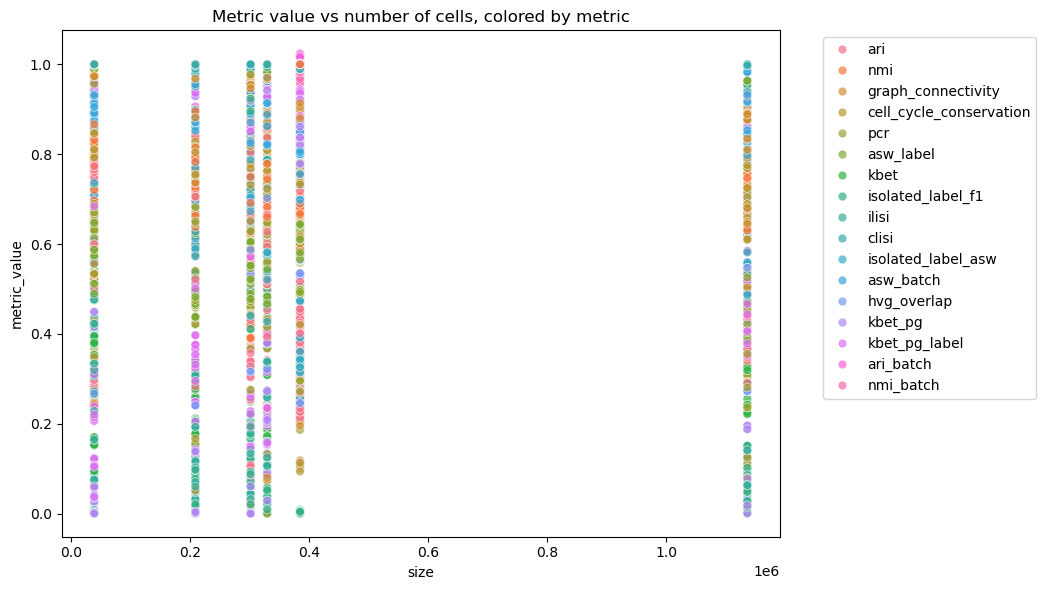

In [90]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="size",
    y="metric_value",
    hue="metric_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs number of cells, colored by metric")
plt.tight_layout()

# Move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### metric value - nested batches

In [91]:
df["nested_batches"] = (
    df["nested_batches"]
    .fillna("Unknown")            # replace NaN with "Unknown"
    .astype(str)                  # ensure string
    .str.capitalize()             # make it 'Yes', 'No', 'Unknown'
)

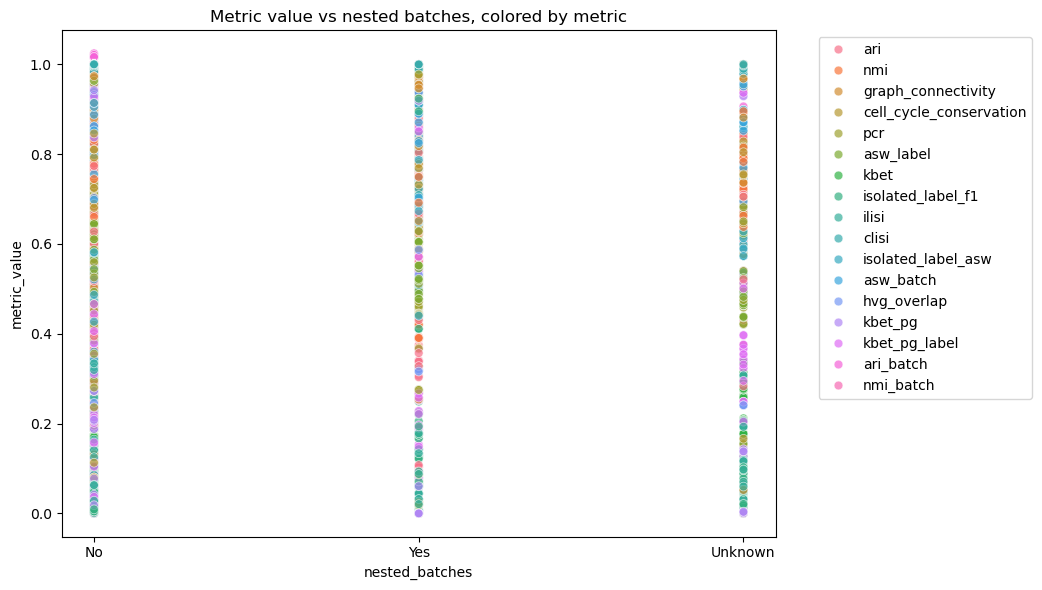

In [95]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="nested_batches",
    y="metric_value",
    hue="metric_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs nested batches, colored by metric")
plt.tight_layout()

# Move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


### batch imbalance

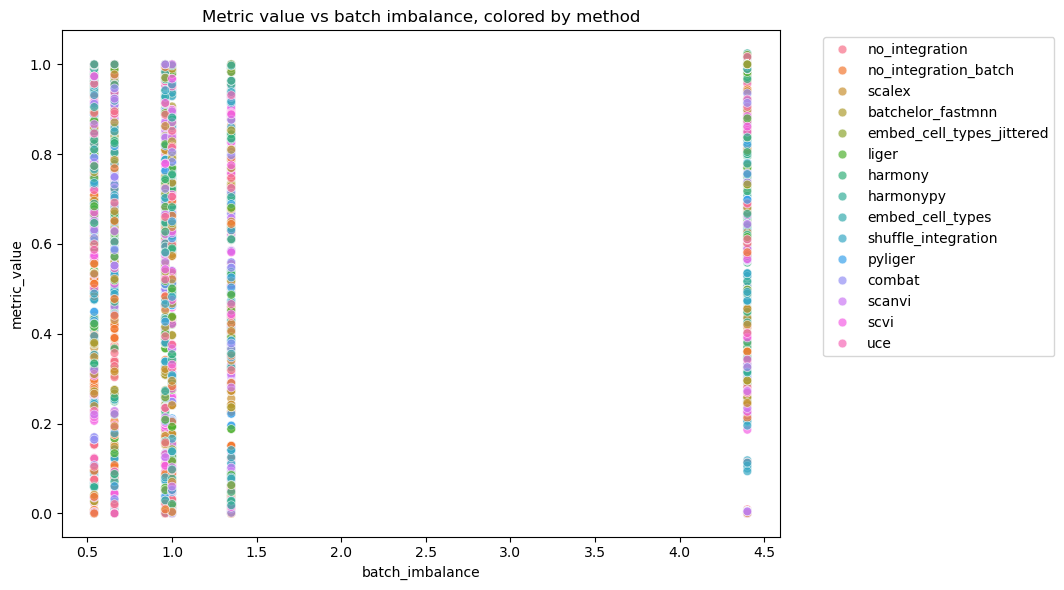

In [96]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="batch_imbalance",
    y="metric_value",
    hue="method_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs batch imbalance, colored by method")
plt.tight_layout()

# Move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

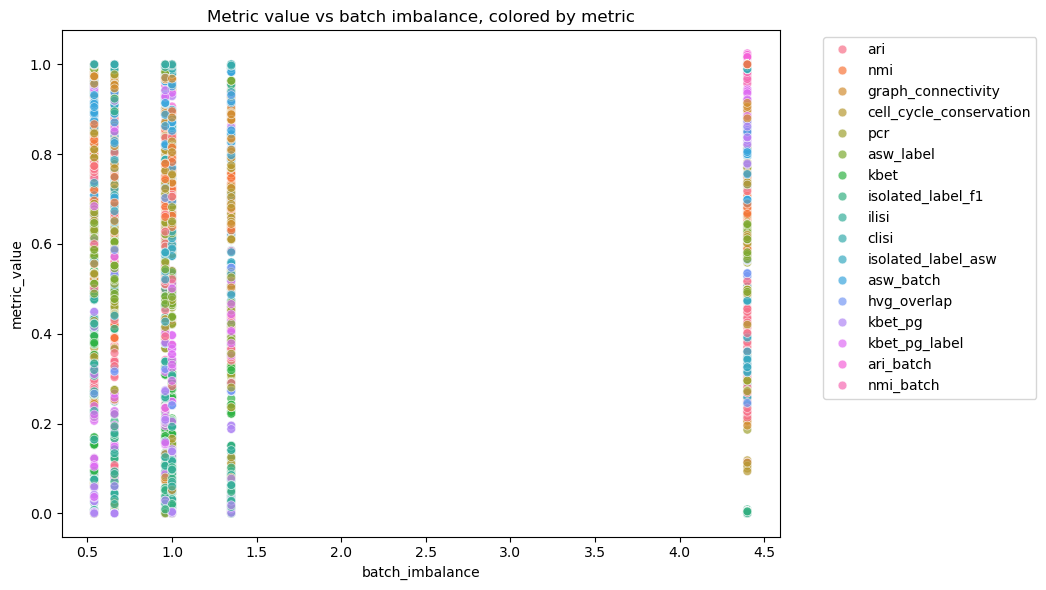

In [98]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="batch_imbalance",
    y="metric_value",
    hue="metric_id",      # <-- color by metric
    alpha=0.7,
    s=40
)

plt.title("Metric value vs batch imbalance, colored by metric")
plt.tight_layout()

# Move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### Performance per Organism

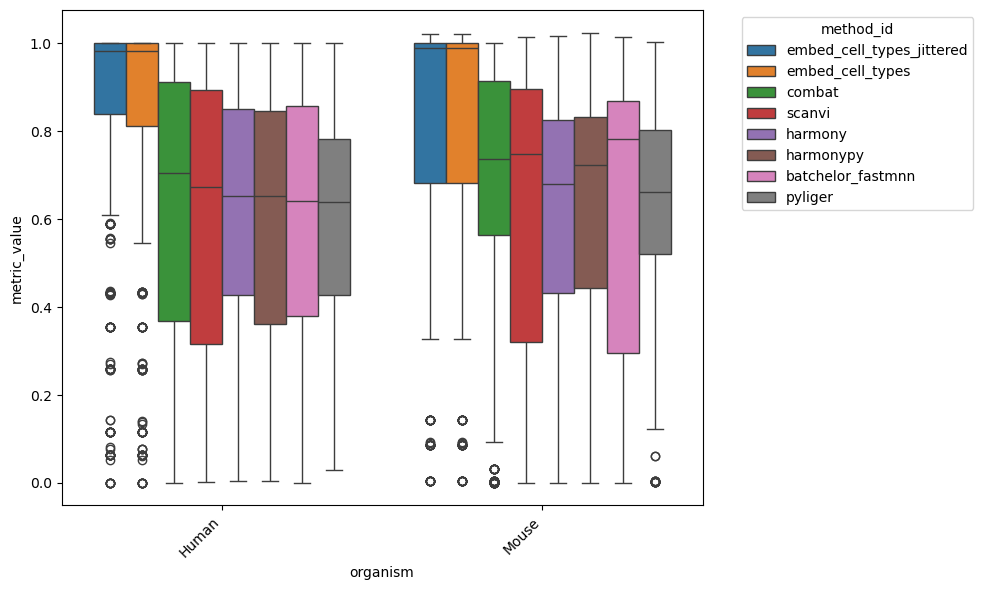

In [99]:
# Compute average metric per method to order them
order = df.groupby("method_id")["metric_value"].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(
    x="organism", y="metric_value", hue="method_id",
    data=df, order=None, hue_order=order[:8]  # show only top 8 methods
)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="method_id")
plt.tight_layout()
plt.show()

take all methods

human and mouse separately?

maybe violin plot will be a bit more informative

you can add median and stuff to that

GROUP BY METRIC (different metrics have different distributions so don't put them all together, they are not scaled - 0.2 NMI method1 is not the same as 0.2 ARI method2)

minmax scale across the whole table

### Correlation between metrics

In [103]:
metric_wide = df.pivot_table(
    index=["dataset_id", "method_id"],
    columns="metric_id",
    values="metric_value",
    aggfunc="first"
)
corr_metrics = metric_wide.corr()


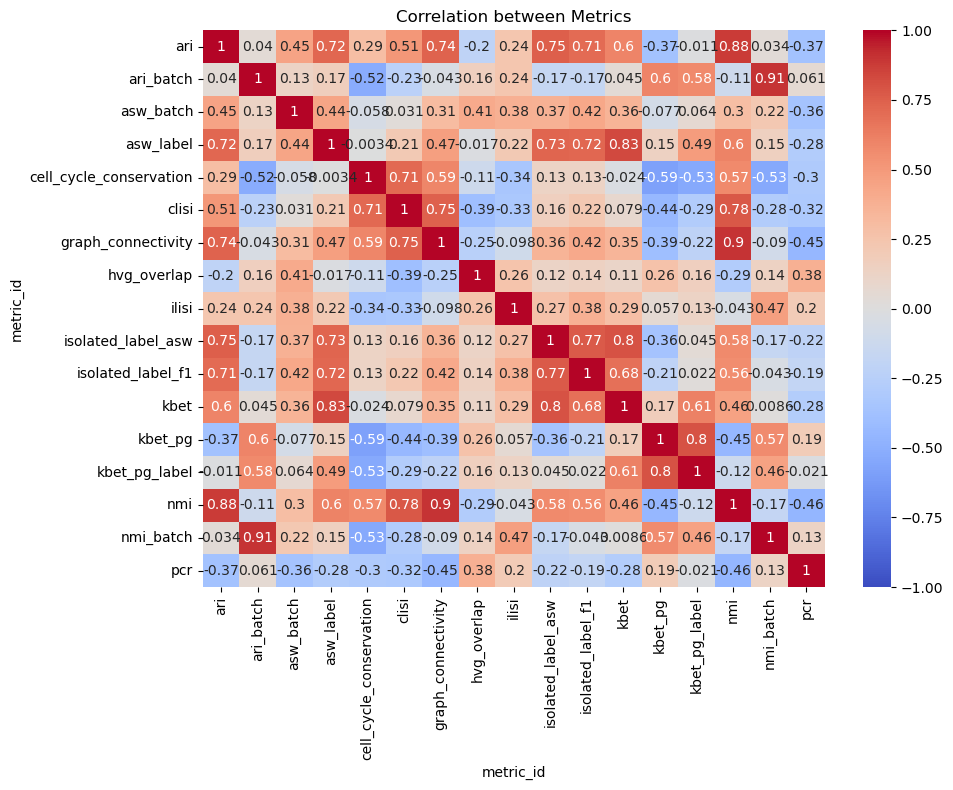

In [104]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_metrics,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Correlation between Metrics")
plt.tight_layout()
plt.show()

- ari-nmi: 0.88
- ari_batch - nmi_batch: 0.91
- graph_connectivity - nmi: 0.9

ari nmi - clustering metrics

High correlation between graph connectivity and nmi is not expected: is it a bad thing? graph connectivity-batch?or celltype?

higly negatively correlated metrics are also informative - batch vs cell type? or batch & batch? 

maybe cluster the metrics? (seaborn clustermap dendogram)

scatterplot of two correlated metrics

BTW corr() is default pearson:

In [123]:
metric_wide

metric_id                                      ari  ari_batch  asw_batch  \
dataset_id     method_id                                                   
dkd            batchelor_fastmnn          0.765456   0.962341   0.893977   
               combat                     0.770070   0.966763   0.912260   
               embed_cell_types           1.000000   0.966888   0.961330   
               embed_cell_types_jittered  1.000000   0.966888   0.961135   
               harmony                    0.788582   0.962395   0.906075   
...                                            ...        ...        ...   
tabula_sapiens scalex                     0.340581   0.942543   0.786411   
               scanvi                     0.518676   0.939689   0.810081   
               scvi                       0.458248   0.945516   0.827786   
               shuffle_integration       -0.000018   1.000077   0.912218   
               uce                        0.459182   0.937488   0.931366   

metric_id                                 asw_label  cell_cycle_conservation  \
dataset_id     method_id                                                       
dkd            batchelor_fastmnn           0.665682                 0.857370   
               combat                      0.612954                 0.792523   
               embed_cell_types            0.989698                 0.811014   
               embed_cell_types_jittered   0.989690                 0.809907   
               harmony                     0.646759                 0.849483   
...                                             ...                      ...   
tabula_sapiens scalex                      0.458957                 0.694257   
               scanvi                      0.547264                 0.667335   
               scvi                        0.507872                 0.676562   
               shuffle_integration         0.419284                 0.113417   
               uce                         0.507080                 0.768180   

metric_id                                    clisi  graph_connectivity  \
dataset_id     method_id                                                 
dkd            batchelor_fastmnn          1.000000            0.973900   
               combat                     0.999727            0.972781   
               embed_cell_types           1.000000            1.000000   
               embed_cell_types_jittered  1.000000            1.000000   
               harmony                    1.000000            0.974664   
...                                            ...                 ...   
tabula_sapiens scalex                     0.995873            0.730005   
               scanvi                     0.999901            0.927071   
               scvi                       0.999252            0.890838   
               shuffle_integration        0.938254            0.017076   
               uce                        0.998287            0.891117   

metric_id                                 hvg_overlap     ilisi  \
dataset_id     method_id                                          
dkd            batchelor_fastmnn                  NaN  0.273009   
               combat                        0.664909  0.164374   
               embed_cell_types                   NaN  0.431047   
               embed_cell_types_jittered          NaN  0.433142   
               harmony                            NaN  0.332332   
...                                               ...       ...   
tabula_sapiens scalex                        0.269241  0.015635   
               scanvi                             NaN  0.007548   
               scvi                               NaN  0.014564   
               shuffle_integration           0.492483  0.140828   
               uce                                NaN  0.022230   

metric_id                                 isolated_label_asw  \
dataset_id     method_id                                       
dkd    

<Axes: xlabel='ari', ylabel='nmi'>

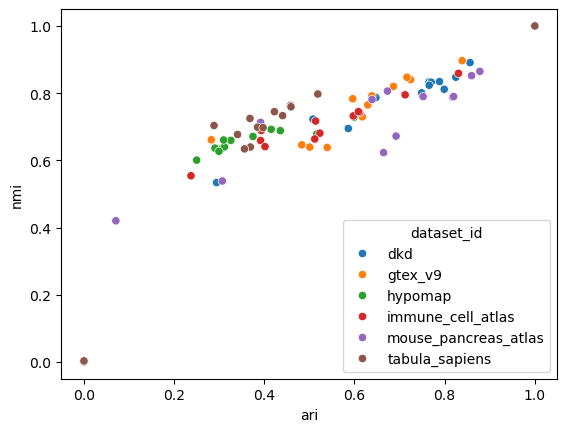

In [125]:
sns.scatterplot(data=metric_wide, x="ari", y="nmi", hue="dataset_id")

this is not exactly x=y so maybe try spearman for corr

the outliers (0,0),(1,1) - probs control methods, maybe kick them out

maybe color by methods/dataset

<Axes: xlabel='ari', ylabel='nmi'>

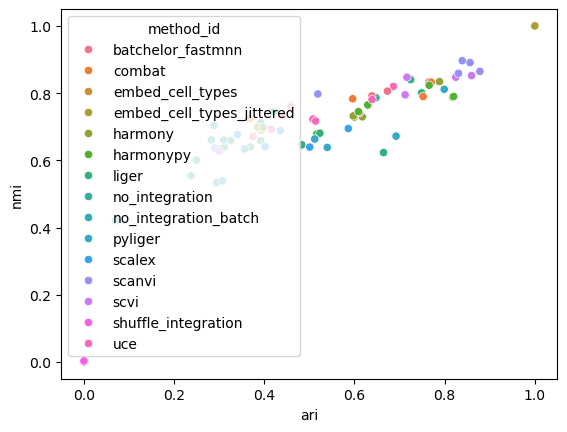

In [126]:
sns.scatterplot(data=metric_wide, x="ari", y="nmi", hue="method_id")

maybe group them to embedding vs knn vs .. and color

or control method vs non-control

### each metric against dataset feature

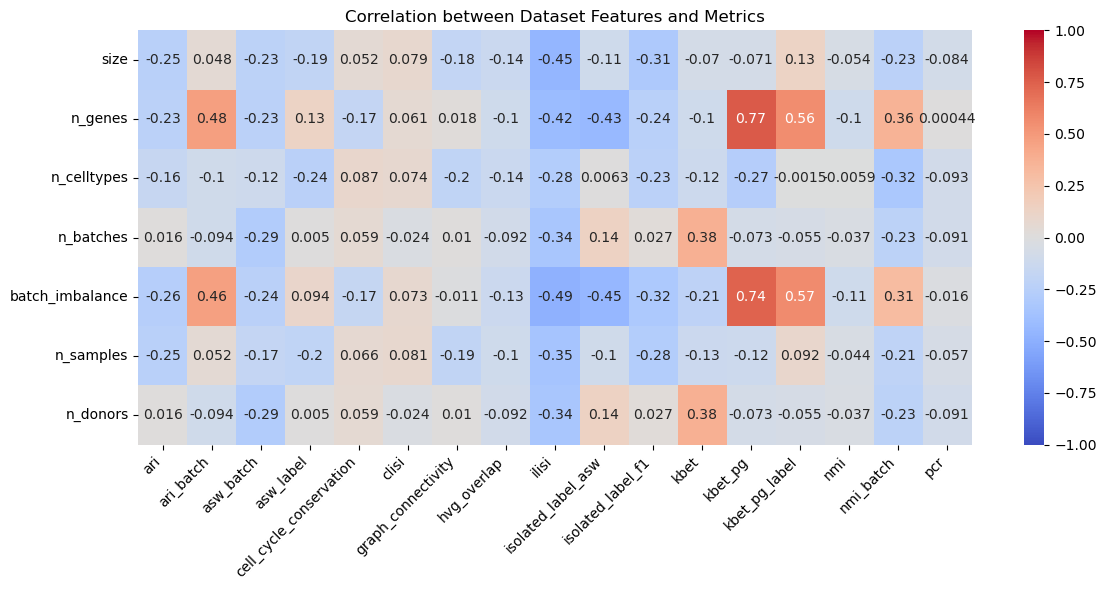

In [106]:
features = df[[
    "dataset_id", "size", "n_genes", "n_celltypes",
    "n_batches", "batch_imbalance", "n_samples", "n_donors"
]].drop_duplicates()

merged = features.set_index("dataset_id").join(metric_wide)
corr = merged.corr()

feature_cols = ["size", "n_genes", "n_celltypes",
                "n_batches", "batch_imbalance", "n_samples", "n_donors"]

metric_cols = metric_wide.columns.tolist()

corr_block = corr.loc[feature_cols, metric_cols]

plt.figure(figsize=(12, 6))
sns.heatmap(
    corr_block,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1
)
plt.title("Correlation between Dataset Features and Metrics")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- n_genes-kbet_pg: 0.77
- batch_imbalance-kbet_pg: 0.74 -> note that kbet is biased by batch size imbalance

Note that high correlation doesn't mean objectively high/low scores, just how biased it can be

n_genes - batch_imbalance correlation - check, it might be confounding

same thing as metric-metric correlation, do scatter plots

defo use spearman

### Biological conservation metrics vs Batch removal metrics

In [112]:
# sort alphabetically for better comparison

method_order = sorted(df[df["metric_id"] == "ari"]["method_id"].unique())

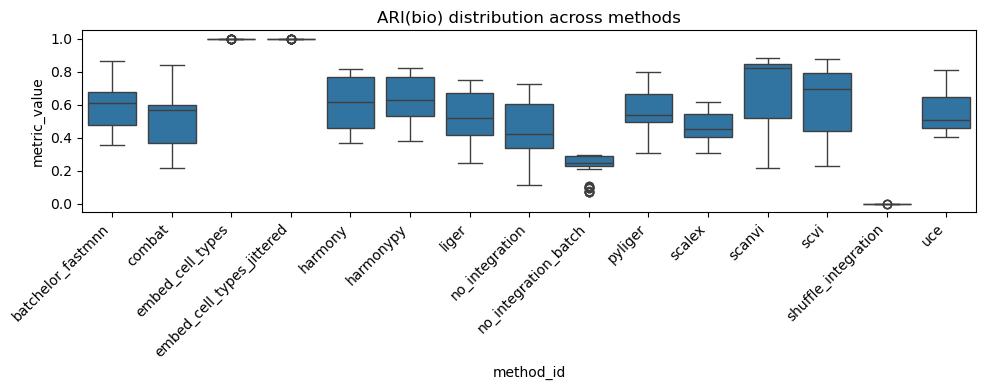

In [113]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df[df["metric_id"] == "ari"], x="method_id", y="metric_value", order=method_order)
plt.title("ARI(bio) distribution across methods")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


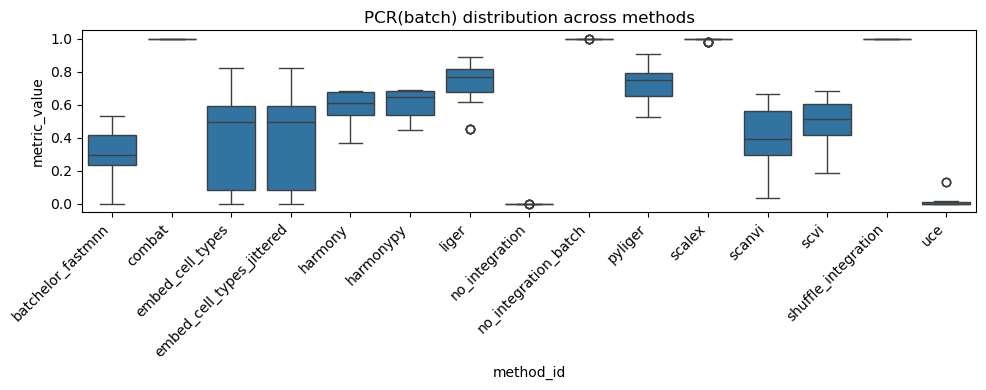

In [114]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df[df["metric_id"] == "pcr"], x="method_id", y="metric_value", order=method_order)
plt.title("PCR(batch) distribution across methods")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- combat: batch
- embed: one-hot encoding (control method)
- liger: bio?
- no_integration: (control method)
- scalex: batch
- shuffle_integration:randomly integrated (control method)
- uce: bio

PER METRIC

if you have methods in the x-axis you're comparing methods

check scib paper- correlation and stufff

In [118]:
bio_metrics = [
    'ari',
    'nmi',
    'graph_connectivity',
    'cell_cycle_conservation',
    'asw_label',
    'isolated_label_f1',
    'isolated_label_asw',
    'hvg_overlap',
]

batch_metrics = [
    'pcr',
    'kbet',
    'ilisi',
    'clisi',
    'asw_batch',
    'kbet_pg',
    'kbet_pg_label',
    'ari_batch',
    'nmi_batch',
]

clean = df.dropna(subset=["metric_value", "metric_id", "method_id"])

bio_scores = (
    clean[clean["metric_id"].isin(bio_metrics)]
    .groupby("method_id")["metric_value"]
    .mean()
    .rename("bio_score")
)

batch_scores = (
    clean[clean["metric_id"].isin(batch_metrics)]
    .groupby("method_id")["metric_value"]
    .mean()
    .rename("batch_score")
)

summary = (
    pd.concat([bio_scores, batch_scores], axis=1)
      .dropna()
      .sort_index()  # alphabetical by method_id
)

print(summary)

                           bio_score  batch_score
method_id                                        
batchelor_fastmnn           0.652199     0.543544
combat                      0.629843     0.625031
embed_cell_types            0.945931     0.673669
embed_cell_types_jittered   0.946540     0.676006
harmony                     0.633664     0.592759
harmonypy                   0.645539     0.560853
liger                       0.556936     0.641384
no_integration              0.641157     0.427108
no_integration_batch        0.496165     0.575207
pyliger                     0.568444     0.638111
scalex                      0.511744     0.643344
scanvi                      0.710641     0.524357
scvi                        0.654463     0.528916
shuffle_integration         0.205955     0.692501
uce                         0.611990     0.484766


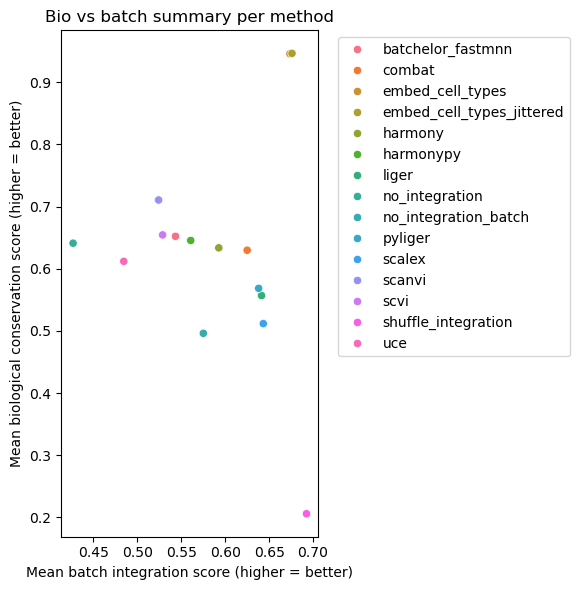

In [122]:
plt.figure(figsize=(6,6))
ax = sns.scatterplot(
    data=summary.reset_index(),
    x="batch_score",
    y="bio_score",
    hue="method_id"  # optional, or drop if too noisy
)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.xlabel("Mean batch integration score (higher = better)")
plt.ylabel("Mean biological conservation score (higher = better)")
plt.title("Bio vs batch summary per method")

# # Optional: label points with method_id
# for _, row in summary.reset_index().iterrows():
#     ax.text(
#         row["batch_score"],
#         row["bio_score"],
#         row["method_id"],
#         fontsize=8,
#         ha="left",
#         va="center"
#     )

plt.tight_layout()
plt.show()


probs need to scale the values beforehand

if you see correlation, see scatterplot

consider *confounding*

confounding - there's another reason/cause for something besides what we're expecting

correlation is not causation